# Kepler Light Curve — Trend, Variability & Uncertainty

**DS-III Data Visualization — Time Series Assignment**

Dataset: KIC 11395018, Kepler long-cadence stitched light curve
(`hlsp_kepler.fits`, extension `LIGHTCURVE_STITCHED`).

Source: https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html

Deliverable: STL decomposition for trend/seasonality, a rolling 95%
uncertainty band combining pipeline `flux_err` with systematic rolling
std, and a temporal-honesty note on cadence, quarter gaps, and axis
scaling.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
from pathlib import Path
from statsmodels.tsa.seasonal import STL

alt.data_transformers.disable_max_rows()
print('pandas   ', pd.__version__)
print('numpy    ', np.__version__)
print('altair   ', alt.__version__)

pandas    3.0.6
numpy     2.4.6
altair    6.3.0


In [3]:
HERE = Path.cwd()
DATA_FILE = HERE / 'kic11395018_lightcurve.csv'
print('Looking for:', DATA_FILE)
print('Exists:', DATA_FILE.exists())

df = pd.read_csv(DATA_FILE).sort_values('time').reset_index(drop=True)

epoch = pd.Timestamp('2009-05-02')
df['datetime'] = epoch + pd.to_timedelta(df['time'], unit='D')

median_flux = df['flux'].median()
df['rel_flux'] = df['flux'] / median_flux
df['rel_flux_err'] = df['flux_err'] / median_flux

if 'sap_quality' in df.columns:
    df['sap_quality'] = df['sap_quality'].fillna(0).astype(int)
else:
    df['sap_quality'] = 0

print(f'Rows: {len(df):,}')
df.head()

Looking for: C:\Users\Jael Rojas\Documents\MS_DataScience\DS_III semester\DV\Assig\HW4\kic11395018_lightcurve.csv
Exists: True
Rows: 33,919


,time,cadenceno,quarter,flux,flux_err,sap_flux,sap_flux_err,psf_flat_flux,psf_flat_flux_err,sap_quality,flatten_mask,datetime,rel_flux,rel_flux_err
0,120.539047,568,0,207608.598373,12.940405,155035.638167,12.845796,207281.349466,13.316124,0,0,2009-08-30 12:56:13.680272693,0.998546,0.000062
1,120.559482,569,0,207647.726755,12.928679,155064.858024,12.841299,207333.190154,13.288711,8192,0,2009-08-30 13:25:39.202259482,0.998735,0.000062
2,120.579916,570,0,207735.445986,12.917207,155130.364016,12.836728,207433.379461,13.243274,8192,0,2009-08-30 13:55:04.715596136,0.999156,0.000062
3,120.600350,571,0,207811.394203,12.905490,155187.079779,12.831645,207521.569879,13.207298,0,0,2009-08-30 14:24:30.246233042,0.999522,0.000062
4,120.620784,572,0,207889.158139,12.894416,155245.151466,12.826937,207611.346983,13.173178,0,0,2009-08-30 14:53:55.768219831,0.999896,0.000062


## STL decomposition

Trend, seasonal (7-day), and residual components on the daily-binned
series.

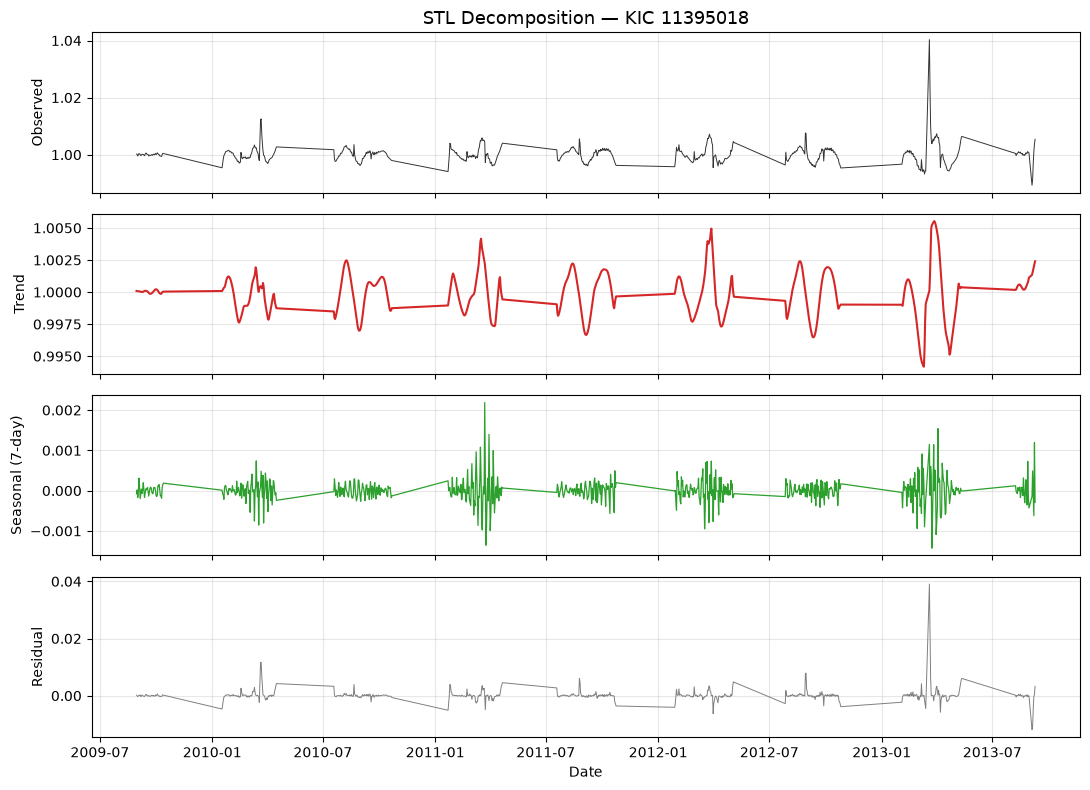

In [4]:
daily = (
    df.set_index('datetime')['rel_flux']
      .resample('1D').mean().dropna()
)
res = STL(daily, period=7, robust=True).fit()

stl_df = pd.DataFrame({
    'date': daily.index,
    'observed': daily.values,
    'trend': res.trend.values,
    'seasonal': res.seasonal.values,
    'resid': res.resid.values,
})

fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True)
axes[0].plot(stl_df['date'], stl_df['observed'], color='#333', lw=0.7)
axes[0].set_ylabel('Observed')
axes[0].set_title('STL Decomposition — KIC 11395018', fontsize=13)
axes[1].plot(stl_df['date'], stl_df['trend'], color='#d62728', lw=1.5)
axes[1].set_ylabel('Trend')
axes[2].plot(stl_df['date'], stl_df['seasonal'], color='#2ca02c', lw=0.9)
axes[2].set_ylabel('Seasonal (7-day)')
axes[3].plot(stl_df['date'], stl_df['resid'], color='#7f7f7f', lw=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Main chart — Light curve with uncertainty band

Rolling ±1.96σ combining pipeline photon noise and rolling systematics.

In [5]:
RESOLUTION = 'Daily bins'
rule = {'Native': None, '6-hour bins': '6h', 'Daily bins': '1D'}[RESOLUTION]

if rule is None:
    plot_df = df[['datetime','rel_flux','rel_flux_err']].rename(columns={'datetime':'date'}).reset_index(drop=True)
else:
    plot_df = (df.set_index('datetime')
                 .resample(rule)
                 .agg({'rel_flux':'mean','rel_flux_err':'mean'})
                 .dropna().reset_index()
                 .rename(columns={'datetime':'date'}))

window = {'Native':200,'6-hour bins':14,'Daily bins':7}[RESOLUTION]
roll_mean = plot_df['rel_flux'].rolling(window, center=True, min_periods=1).mean()
roll_std  = plot_df['rel_flux'].rolling(window, center=True, min_periods=1).std()
sigma = np.sqrt(roll_std.fillna(0)**2 + plot_df['rel_flux_err'].fillna(0)**2)

band_df = pd.DataFrame({'date': plot_df['date'], 'mean': roll_mean,
                        'lower': roll_mean - 1.96*sigma,
                        'upper': roll_mean + 1.96*sigma})

band = alt.Chart(band_df).mark_area(opacity=0.25, color='#4c78a8').encode(
    x=alt.X('date:T', title='Date'),
    y=alt.Y('lower:Q', title='Relative flux', scale=alt.Scale(zero=False)),
    y2='upper:Q')
line = alt.Chart(band_df).mark_line(color='#1f4e79', strokeWidth=1.5).encode(x='date:T', y='mean:Q')
points = (alt.Chart(plot_df).mark_circle(size=5, opacity=0.25, color='#555')
          .encode(x='date:T', y='rel_flux:Q',
                  tooltip=['date:T', alt.Tooltip('rel_flux:Q', format='.5f')]))
(band + line + points).properties(height=380).interactive()

alt.LayerChart(...)

## Temporal-honesty note

- Cadence: Kepler long-cadence integrates 29.4 min per point; binning removes real short-period variability.
- Quarter gaps: plotted on a real-time axis so ~1-day downlinks appear as gaps.
- Quality flags: kept in by default; the Streamlit app exposes a toggle.
- Axis scaling: `zero=False` because relative flux is ~0.99–1.01; uncertainty band combines pipeline `flux_err` with rolling std.